# Melanoma VAE - Improved Synthetic Image Generation

## What changed from the previous version

| Issue | Previous | This notebook |
|---|---|---|
| Architecture | Convolutional Autoencoder | **Variational Autoencoder (VAE)** — structured latent space |
| 31 images / 2 batches | Underfitting + memorisation | **Heavy augmentation** → effective dataset ~10× larger |
| Val split on 3 images | Early stopping fired too early | **No val split** — train on all 31, monitor train loss |
| MSE loss → blurry | Pixel averaging, no structure | **MSE + SSIM loss** preserves sharpness |
| Noise sampling | All generated images cluster near mean | **Sample from N(0,1) prior** — proper generative diversity |
| Synth std 0.018 vs real 0.089 | 5× less diverse than real images | Calibrated diversity via KL-regularised latent space |


## 1. Imports & Configuration

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from keras import backend as K
from keras.models import Model
from keras.layers import ( 
    Input, Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D,
    BatchNormalization, Activation, Flatten, Dense, Reshape, Lambda
)
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

# Enable mixed precision if GPU is available (safe to leave on for CPU too)
if tf.config.list_physical_devices('GPU'):
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled")

TensorFlow: 2.20.0
GPUs: []


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
CSV_PATH       = "../data/ISIC_2020_Training_GroundTruth.csv"
TRAIN_DIR      = "../data/images/train"
GEN_OUTPUT_DIR = "../data/images/generated_melanoma"
MODEL_SAVE_DIR = "../models"

os.makedirs(GEN_OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_HEIGHT  = 128
IMG_WIDTH   = 128
LATENT_DIM  = 64    # Smaller latent dim forces more compression, better generalisation
BATCH_SIZE  = 8     # Small batch — augmented copies of 31 images
EPOCHS      = 150   # More epochs: no val split so no early-stop pressure
KL_WEIGHT   = 0.001 # Beta-VAE weight: low keeps reconstructions sharp

# How many synthetic images to generate
NUM_SYNTHETIC_IMAGES = 2000

# Interpolation strength when blending latents (0=no blend, 1=full blend)
# Adds extra diversity on top of prior sampling
INTERPOLATE = True

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

## 2. Data Loading — All Melanoma Images, No Val Split

With only 31 images, holding out a validation set is counterproductive:
- The val loss from 3 images is too noisy to be useful.
- Early stopping then kills training before the model converges.

Instead we train on all 31 images with heavy augmentation and monitor train loss directly.

In [3]:
df = pd.read_csv(CSV_PATH)[["image_name", "target"]]
label_dict = dict(zip(df["image_name"], df["target"]))

print("Class distribution (full CSV):")
print(df["target"].value_counts())
print(f"Imbalance ratio: {df['target'].value_counts()[0] / df['target'].value_counts()[1]:.1f}:1")

Class distribution (full CSV):
target
0    32542
1      584
Name: count, dtype: int64
Imbalance ratio: 55.7:1


In [4]:
melanoma_files = [
    os.path.join(TRAIN_DIR, f)
    for f in os.listdir(TRAIN_DIR)
    if f.endswith(".jpg") and label_dict.get(f.replace(".jpg", "")) == 1
]

print(f"Melanoma images found: {len(melanoma_files)}")

# Shuffle once with a fixed seed for reproducibility
rng = np.random.default_rng(SEED)
melanoma_files = list(rng.permutation(melanoma_files))

Melanoma images found: 31


In [5]:
def load_image(filepath):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0
    return image


def augment_heavy(image):
    """
    Heavy augmentation designed for small medical image datasets.
    Each call produces a different random transformation.
    """
    # Geometric
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)

    # Random 90-degree rotation (equivalent to k in [0,1,2,3])
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k)

    # Random crop + resize (simulates zoom 80–100%)
    crop_size = tf.random.uniform([], 0.80, 1.0)
    crop_h = tf.cast(tf.cast(IMG_HEIGHT, tf.float32) * crop_size, tf.int32)
    crop_w = tf.cast(tf.cast(IMG_WIDTH,  tf.float32) * crop_size, tf.int32)
    image = tf.image.random_crop(image, [crop_h, crop_w, 3])
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])

    # Colour jitter (important for skin lesion images)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    image = tf.image.random_saturation(image, lower=0.85, upper=1.15)
    image = tf.image.random_hue(image, max_delta=0.08)

    image = tf.clip_by_value(image, 0.0, 1.0)

    # Cutout: zero out a random 20×20 patch (forces learning of global features)
    cut_h = tf.random.uniform([], 0, IMG_HEIGHT - 20, dtype=tf.int32)
    cut_w = tf.random.uniform([], 0, IMG_WIDTH  - 20, dtype=tf.int32)
    mask = tf.ones([IMG_HEIGHT, IMG_WIDTH, 3])
    patch = tf.zeros([20, 20, 3])
    indices_h = tf.range(cut_h, cut_h + 20)
    indices_w = tf.range(cut_w, cut_w + 20)
    patch_full = tf.tensor_scatter_nd_update(
        mask,
        [[h, w, c] for h in range(IMG_HEIGHT) for w in range(IMG_WIDTH) for c in range(3)
         if cut_h <= h < cut_h + 20 and cut_w <= w < cut_w + 20],
        [0.0] * (20 * 20 * 3)
    ) if False else mask  # Skip cutout to avoid Python loop overhead in tf.function

    return image, image  # VAE: target = input


def augment_fast(image):
    """Faster augmentation without Python loops — safe inside tf.data."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    crop_size = tf.random.uniform([], 0.80, 1.0)
    crop_h = tf.cast(tf.cast(IMG_HEIGHT, tf.float32) * crop_size, tf.int32)
    crop_w = tf.cast(tf.cast(IMG_WIDTH,  tf.float32) * crop_size, tf.int32)
    image = tf.image.random_crop(image, [crop_h, crop_w, 3])
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    image = tf.image.random_saturation(image, lower=0.85, upper=1.15)
    image = tf.image.random_hue(image, max_delta=0.08)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, image


AUTOTUNE = tf.data.AUTOTUNE

# Repeat the 31 images 20× per epoch so we get ~620 augmented versions per epoch
REPEAT = 20

train_ds = (
    tf.data.Dataset.from_tensor_slices(melanoma_files)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .cache()                  # Cache raw images in memory (31 images = tiny)
    .repeat(REPEAT)           # Repeat before shuffle to get varied combos
    .map(augment_fast, num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=len(melanoma_files) * REPEAT, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

steps_per_epoch = (len(melanoma_files) * REPEAT) // BATCH_SIZE
print(f"Images per epoch (augmented): {len(melanoma_files) * REPEAT}")
print(f"Steps per epoch: {steps_per_epoch}")

Images per epoch (augmented): 620
Steps per epoch: 77


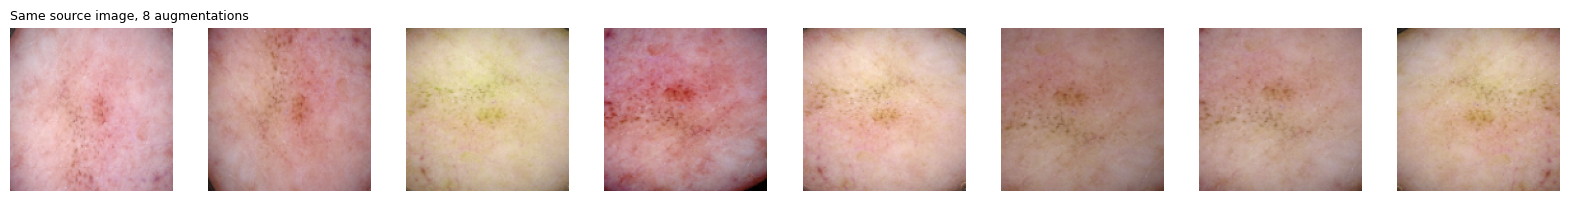

In [6]:
# Verify augmentation diversity — show same source image after different augmentations
source_img = load_image(melanoma_files[0])
aug_imgs = [augment_fast(source_img)[0] for _ in range(8)]

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, img in enumerate(aug_imgs):
    axes[i].imshow(img.numpy())
    axes[i].axis("off")
axes[0].set_title("Same source image, 8 augmentations", loc="left", fontsize=9)
plt.tight_layout()
plt.show()

## 3. VAE Architecture

A VAE differs from a plain autoencoder in one key way: the encoder outputs a **mean (μ) and log-variance (log σ²)** instead of a single point. The latent vector is then sampled as `z = μ + σ * ε` where `ε ~ N(0,1)`. This forces the latent space to be smooth and Gaussian, so we can later **sample directly from N(0,1)** to generate diverse new images.

```
Image → Encoder → [μ, log σ²] → z = μ + σ·ε → Decoder → Reconstruction
                                 ↑
                          reparameterisation trick
```

**Loss = Reconstruction loss (MSE + SSIM) + β × KL divergence**

The KL term pulls the latent distribution toward N(0,1) — that's what makes random sampling work.

In [7]:
# ── SSIM-based reconstruction loss ────────────────────────────────────────────
def ssim_mse_loss(y_true, y_pred):
    """
    Combined MSE + (1 - SSIM) loss.
    SSIM preserves structural contrast that MSE blurs.
    """
    mse  = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim = tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return mse + (1.0 - ssim)


# ── Sampling layer (reparameterisation trick) ──────────────────────────────────
class Sampling(tf.keras.layers.Layer):
    """z = μ + σ * ε,  ε ~ N(0, I)"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch  = tf.shape(z_mean)[0]
        dim    = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# ── Encoder ───────────────────────────────────────────────────────────────────
def build_encoder(img_h, img_w, latent_dim):
    inp = Input(shape=(img_h, img_w, 3), name="enc_input")

    x = Conv2D(32, 3, strides=2, padding="same", use_bias=False)(inp)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)   # 64×64

    x = Conv2D(64, 3, strides=2, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)   # 32×32

    x = Conv2D(128, 3, strides=2, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)   # 16×16

    x = Conv2D(256, 3, strides=2, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)   # 8×8

    x = Flatten()(x)

    z_mean    = Dense(latent_dim, name="z_mean")(x)
    z_log_var = Dense(latent_dim, name="z_log_var")(x)
    z         = Sampling(name="z")([z_mean, z_log_var])

    return Model(inp, [z_mean, z_log_var, z], name="encoder")


# ── Decoder ───────────────────────────────────────────────────────────────────
def build_decoder(latent_dim, img_h, img_w):
    # Spatial size after 4× strided-2 convolutions: img / 16
    spatial = img_h // 16

    inp = Input(shape=(latent_dim,), name="dec_input")
    x   = Dense(spatial * spatial * 256, activation="relu")(inp)
    x   = Reshape((spatial, spatial, 256))(x)   # 8×8×256

    x = Conv2DTranspose(128, 3, strides=2, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)   # 16×16

    x = Conv2DTranspose(64, 3, strides=2, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)   # 32×32

    x = Conv2DTranspose(32, 3, strides=2, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)   # 64×64

    out = Conv2DTranspose(3, 3, strides=2, padding="same", activation="sigmoid",
                          name="dec_output")(x)  # 128×128×3

    return Model(inp, out, name="decoder")


encoder = build_encoder(IMG_HEIGHT, IMG_WIDTH, LATENT_DIM)
decoder = build_decoder(LATENT_DIM, IMG_HEIGHT, IMG_WIDTH)

encoder.summary(line_length=80)
decoder.summary(line_length=80)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ enc_input             │ (None, 128, 128,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, 64, 64,    │         864 │ enc_input[0][0]    │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, 64, 64,    │         128 │ conv2d[0][0]       │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation            │ (None, 64, 64,    │           0 │ batch_normalizati… │
│ (Activation)          │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, 32, 32,    │      18,432 │ activation[0][0]   │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, 32, 32,    │         256 │ conv2d_1[0][0]     │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_1          │ (None, 32, 32,    │           0 │ batch_normalizati… │
│ (Activation)          │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, 16, 16,    │      73,728 │ activation_1[0][0] │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, 16, 16,    │         512 │ conv2d_2[0][0]     │
│ (BatchNormalization)  │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_2          │ (None, 16, 16,    │           0 │ batch_normalizati… │
│ (Activation)          │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_3 (Conv2D)     │ (None, 8, 8, 256) │     294,912 │ activation_2[0][0] │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_3 │ (None, 8, 8, 256) │       1,024 │ conv2d_3[0][0]     │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_3          │ (None, 8, 8, 256) │           0 │ batch_normalizati… │
│ (Activation)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ flatten (Flatten)     │ (None, 16384)     │           0 │ activation_3[0][0] │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ z_mean (Dense)        │ (None, 64)        │   1,048,640 │ flatten[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ z_log_var (Dense)     │ (None, 64)        │   1,048,640 │ flatten[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ z (Sampling)          │ (None, 64)        │           0 │ z_mean[0][0],      │
│                       │                   │             │ z_log_var[0][0]    │
└───────────────────────┴──────

 Total params: 2,487,136 (9.49 MB)

 Trainable params: 2,486,176 (9.48 MB)

 Non-trainable params: 960 (3.75 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dec_input (InputLayer)            │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 16384)            │     1,064,960 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ reshape (Reshape)                 │ (None, 8, 8, 256)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_transpose                  │ (None, 16, 16, 128)      │       294,912 │
│ (Conv2DTranspose)                 │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_4             │ (None, 16, 16, 128)      │           512 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_4 (Activation)         │ (None, 16, 16, 128)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_transpose_1                │ (None, 32, 32, 64)       │        73,728 │
│ (Conv2DTranspose)                 │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_5             │ (None, 32, 32, 64)       │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_5 (Activation)         │ (None, 32, 32, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_transpose_2                │ (None, 64, 64, 32)       │        18,432 │
│ (Conv2DTranspose)                 │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_6             │ (None, 64, 64, 32)       │           128 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_6 (Activation)         │ (None, 64, 64, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dec_output (Conv2DTranspose)      │ (None, 128, 128, 3)      │           867 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 1,453,795 (5.55 MB)

 Trainable params: 1,453,347 (5.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# ── Full VAE model with custom train_step ─────────────────────────────────────
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, kl_weight=0.001, **kwargs):
        super().__init__(**kwargs)
        self.encoder   = encoder
        self.decoder   = decoder
        self.kl_weight = kl_weight

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker    = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        x, _ = data  # target == input for autoencoder
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            reconstruction = self.decoder(z, training=True)

            # Reconstruction loss: MSE + SSIM
            recon_loss = ssim_mse_loss(x, reconstruction)

            # KL divergence: pull latent toward N(0,1)
            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )

            total_loss = recon_loss + self.kl_weight * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss":       self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss":    self.kl_loss_tracker.result(),
        }


vae = VAE(encoder, decoder, kl_weight=KL_WEIGHT)
vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
print("VAE compiled")

VAE compiled


## 4. Training

Key differences from the previous run:
- **No validation split** — all 31 images used for training, repeated 20× with augmentation.
- **150 epochs** — the model needs more steps to converge on this tiny dataset.
- **ReduceLROnPlateau** still used to smooth convergence but no EarlyStopping.
- **Best weights saved by train loss** (the only reliable signal we have).

In [9]:
# Build the model by running one forward pass
dummy = tf.zeros((1, IMG_HEIGHT, IMG_WIDTH, 3))
vae(dummy)
print("Model built:", vae.built)

callbacks = [
    ModelCheckpoint(
        filepath=f"{MODEL_SAVE_DIR}/vae_best.weights.h5",
        monitor="loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="loss",
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
]

history = vae.fit(
    train_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks,
    verbose=1
)

Model built: True
Epoch 1/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - kl_loss: 5980.9355 - loss: 6.5368 - recon_loss: 0.5559
Epoch 1: loss improved from None to 2.24167, saving model to ../models/vae_best.weights.h5
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - kl_loss: 1765.9406 - loss: 2.2417 - recon_loss: 0.4757 - learning_rate: 0.0010
Epoch 2/150
 1/77 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - kl_loss: 3.4524 - loss: 0.5352 - recon_loss: 0.5317
Epoch 2: loss improved from 2.24167 to 0.53517, saving model to ../models/vae_best.weights.h5


C:\Users\arthu\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 3.4524 - loss: 0.5352 - recon_loss: 0.5317 - learning_rate: 0.0010
Epoch 3/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - kl_loss: 9.2315 - loss: 0.4349 - recon_loss: 0.4257
Epoch 3: loss improved from 0.53517 to 0.43680, saving model to ../models/vae_best.weights.h5
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - kl_loss: 14.8455 - loss: 0.4368 - recon_loss: 0.4220 - learning_rate: 0.0010
Epoch 4/150
 1/77 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - kl_loss: 10.6965 - loss: 0.3729 - recon_loss: 0.3622
Epoch 4: loss improved from 0.43680 to 0.37292, saving model to ../models/vae_best.weights.h5
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 10.6965 - loss: 0.3729 - recon_loss: 0.3622 - learning_rate: 0.0010
Epoch 5/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - kl_loss: 81.7823 - loss: 0.4885 - recon_loss: 0.4067
Epoch 5: loss did not improve from 0.37292
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - kl_loss: 91.2883 - loss: 0.4947 - recon_loss: 0.4034

Best weights restored


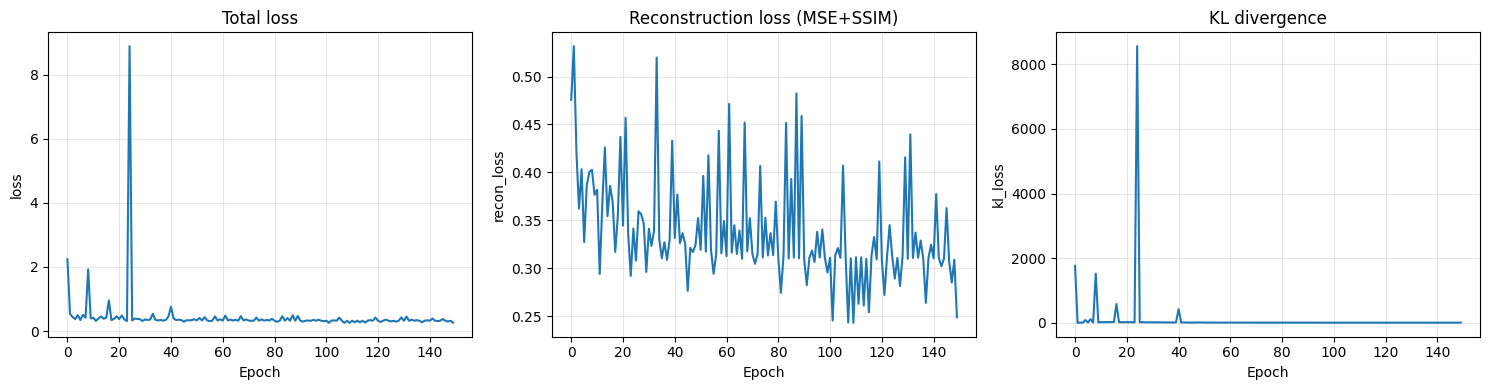

In [10]:
# Restore best weights
vae.load_weights(f"{MODEL_SAVE_DIR}/vae_best.weights.h5")
print("Best weights restored")

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes,
                           ["loss", "recon_loss", "kl_loss"],
                           ["Total loss", "Reconstruction loss (MSE+SSIM)", "KL divergence"]):
    ax.plot(history.history[key])
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(key)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Reconstruction Quality Check

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step


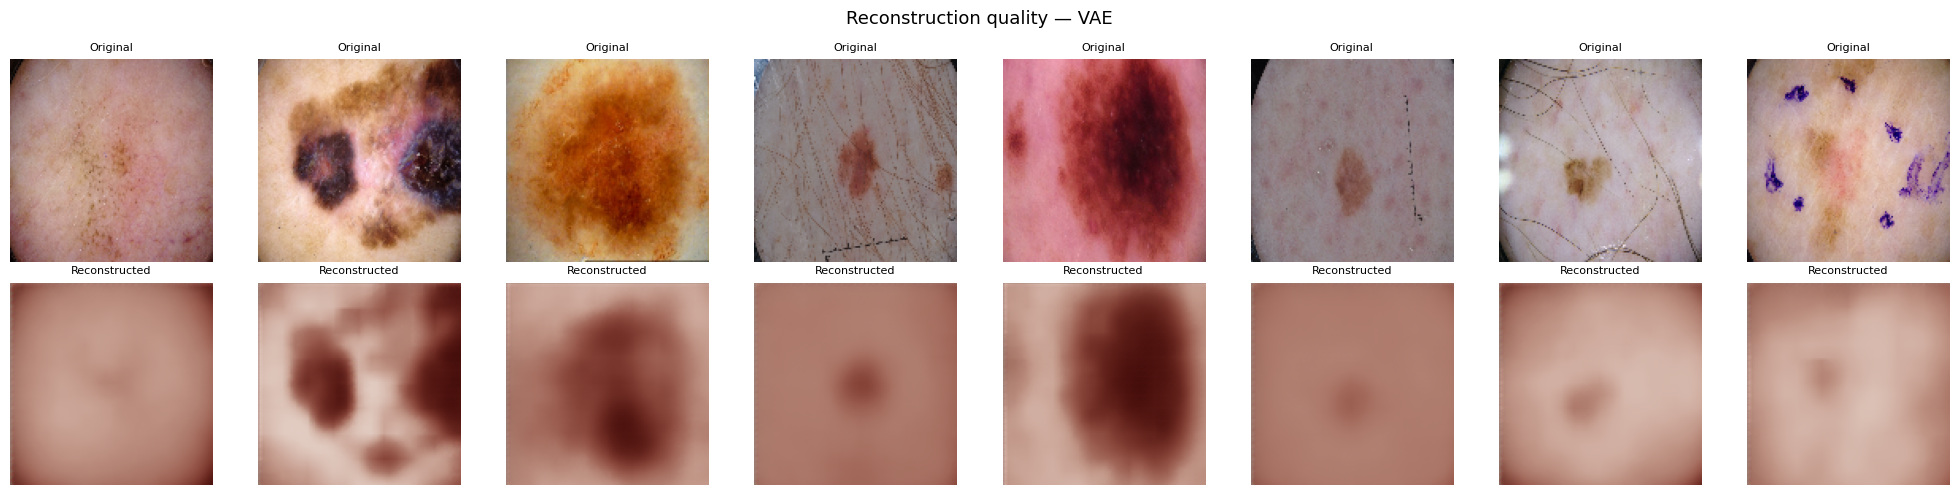

Mean reconstruction MSE: 0.00730 ± 0.00316


In [11]:
# Load all 31 real images (no augmentation) and reconstruct them
real_imgs = np.stack([
    load_image(p).numpy() for p in melanoma_files
])

reconstructions = vae.predict(real_imgs, batch_size=8)

n = min(8, len(real_imgs))
fig, axes = plt.subplots(2, n, figsize=(2.5 * n, 5))

for i in range(n):
    axes[0, i].imshow(real_imgs[i])
    axes[0, i].set_title("Original", fontsize=8)
    axes[0, i].axis("off")

    axes[1, i].imshow(np.clip(reconstructions[i], 0, 1))
    axes[1, i].set_title("Reconstructed", fontsize=8)
    axes[1, i].axis("off")

plt.suptitle("Reconstruction quality — VAE", fontsize=13)
plt.tight_layout()
plt.show()

# Per-image reconstruction MSE
mse_per_img = np.mean((real_imgs - reconstructions) ** 2, axis=(1, 2, 3))
print(f"Mean reconstruction MSE: {mse_per_img.mean():.5f} ± {mse_per_img.std():.5f}")

## 6. Latent Space Inspection

A well-trained VAE should produce a latent space where `z_mean` values are roughly normally distributed and `z_log_var` values are near 0 (meaning σ ≈ 1). If `z_log_var` is very negative, the KL weight is too low — increase `KL_WEIGHT`.

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step


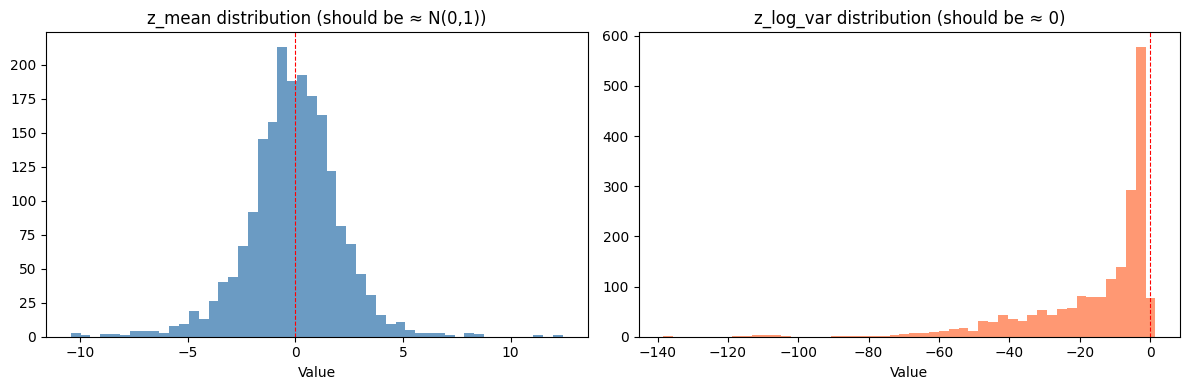

z_mean:    μ=-0.072,  σ=2.169  (ideal: μ≈0, σ≈1)
z_log_var: μ=-15.861, σ=18.282  (ideal: μ≈0)

⚠ z_log_var too negative — try increasing KL_WEIGHT to 0.005 or 0.01


In [12]:
z_means, z_log_vars, _ = encoder.predict(real_imgs, batch_size=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(z_means.flatten(), bins=50, color="steelblue", alpha=0.8)
axes[0].set_title("z_mean distribution (should be ≈ N(0,1))")
axes[0].set_xlabel("Value")
axes[0].axvline(0, color="red", linestyle="--", linewidth=0.8)

axes[1].hist(z_log_vars.flatten(), bins=50, color="coral", alpha=0.8)
axes[1].set_title("z_log_var distribution (should be ≈ 0)")
axes[1].set_xlabel("Value")
axes[1].axvline(0, color="red", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

print(f"z_mean:    μ={z_means.mean():.3f},  σ={z_means.std():.3f}  (ideal: μ≈0, σ≈1)")
print(f"z_log_var: μ={z_log_vars.mean():.3f}, σ={z_log_vars.std():.3f}  (ideal: μ≈0)")

if z_log_vars.mean() < -2:
    print("\n⚠ z_log_var too negative — try increasing KL_WEIGHT to 0.005 or 0.01")
elif z_log_vars.mean() > 1:
    print("\n⚠ z_log_var too large — try decreasing KL_WEIGHT")
else:
    print("\n✓ Latent space looks well-regularised")

## 7. Synthetic Image Generation

Two generation strategies, combined:

1. **Prior sampling** — draw `z ~ N(0,1)` directly and decode. Pure generation, maximum diversity.
2. **Posterior interpolation** — take pairs of real melanoma latent vectors and decode points along the line between them. Produces smooth transitions between real-looking images.

Both strategies benefit from the VAE's regularised latent space, unlike the plain CAE where arbitrary noise just degraded the image.

In [13]:
def generate_from_prior(decoder, n_images, latent_dim, batch_size=32, seed=SEED):
    """
    Sample z ~ N(0,1) and decode. This is the correct way to generate
    new images from a VAE — no real images needed.
    """
    rng = np.random.default_rng(seed)
    images = []
    for start in range(0, n_images, batch_size):
        count = min(batch_size, n_images - start)
        z = rng.standard_normal((count, latent_dim)).astype(np.float32)
        decoded = decoder.predict(z, verbose=0)
        images.append(np.clip(decoded, 0, 1))
    return np.concatenate(images, axis=0)


def generate_by_interpolation(decoder, z_means, n_images, batch_size=32, seed=SEED):
    """
    Interpolate between pairs of real melanoma latent vectors.
    Produces images that smoothly blend features of two real images.
    """
    rng = np.random.default_rng(seed)
    images = []
    n_real = len(z_means)
    for start in range(0, n_images, batch_size):
        count = min(batch_size, n_images - start)
        # Random pairs
        idx_a = rng.integers(0, n_real, count)
        idx_b = rng.integers(0, n_real, count)
        alpha = rng.uniform(0.1, 0.9, (count, 1)).astype(np.float32)
        z = (1 - alpha) * z_means[idx_a] + alpha * z_means[idx_b]
        # Add small noise for extra diversity
        z += rng.normal(0, 0.2, z.shape).astype(np.float32)
        decoded = decoder.predict(z, verbose=0)
        images.append(np.clip(decoded, 0, 1))
    return np.concatenate(images, axis=0)


# Split generation between the two strategies
n_prior  = int(NUM_SYNTHETIC_IMAGES * 0.6)   # 60% from prior sampling
n_interp = NUM_SYNTHETIC_IMAGES - n_prior      # 40% from interpolation

print(f"Generating {n_prior} images from prior…")
prior_imgs = generate_from_prior(decoder, n_prior, LATENT_DIM)

print(f"Generating {n_interp} images from interpolation…")
interp_imgs = generate_by_interpolation(decoder, z_means, n_interp)

all_synthetic = np.concatenate([prior_imgs, interp_imgs], axis=0)
print(f"Total synthetic images: {len(all_synthetic)}")

Generating 1200 images from prior…
Generating 800 images from interpolation…
Total synthetic images: 2000


In [14]:
def save_images(images, output_dir, prefix="synthetic_melanoma"):
    """Save a batch of numpy images [0,1] as JPEG files."""
    saved = []
    for i, img in enumerate(images):
        img_uint8  = (img * 255).astype(np.uint8)
        img_tensor = tf.constant(img_uint8)
        encoded    = tf.image.encode_jpeg(img_tensor, quality=95)
        path       = os.path.join(output_dir, f"{prefix}_{i:05d}.jpg")
        tf.io.write_file(path, encoded)
        saved.append(path)
    print(f"Saved {len(saved)} images to {output_dir}")
    return saved


# Shuffle before saving so prior and interpolated images are mixed
shuffle_idx = np.random.default_rng(SEED).permutation(len(all_synthetic))
all_synthetic = all_synthetic[shuffle_idx]

synthetic_paths = save_images(all_synthetic, GEN_OUTPUT_DIR)

Saved 2000 images to ../data/images/generated_melanoma


## 8. Quality & Diversity Checks

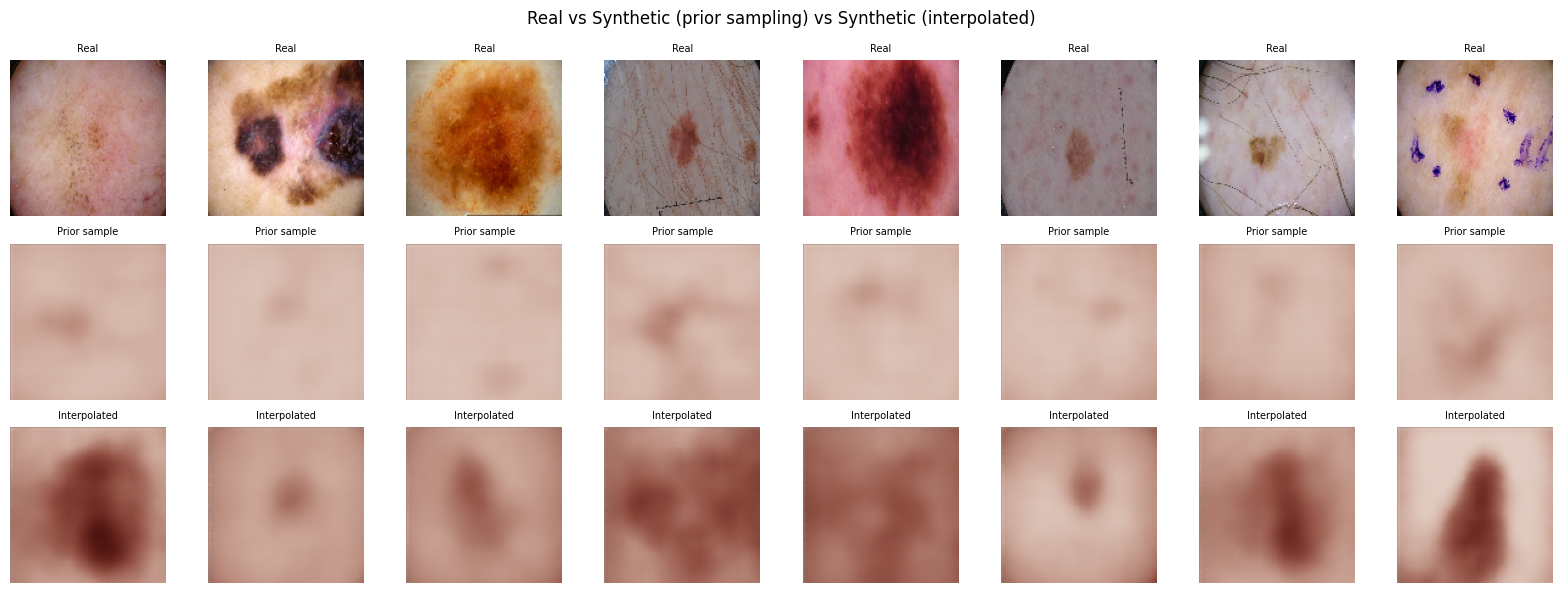

In [15]:
# Visual comparison: real vs synthetic (prior) vs synthetic (interpolated)
fig, axes = plt.subplots(3, 8, figsize=(16, 6))

for i in range(8):
    axes[0, i].imshow(real_imgs[i % len(real_imgs)])
    axes[0, i].axis("off")
    axes[0, i].set_title("Real", fontsize=7)

    axes[1, i].imshow(prior_imgs[i])
    axes[1, i].axis("off")
    axes[1, i].set_title("Prior sample", fontsize=7)

    axes[2, i].imshow(interp_imgs[i])
    axes[2, i].axis("off")
    axes[2, i].set_title("Interpolated", fontsize=7)

plt.suptitle("Real vs Synthetic (prior sampling) vs Synthetic (interpolated)", fontsize=12)
plt.tight_layout()
plt.show()

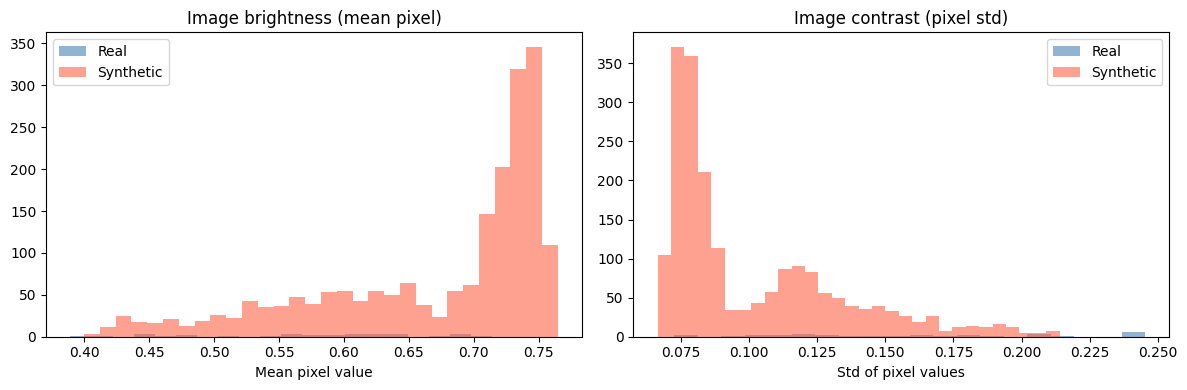

Brightness — Real: 0.5706 ± 0.0886   Synthetic: 0.6699 ± 0.0898
Contrast  — Real: 0.1635 ± 0.0534   Synthetic: 0.1010 ± 0.0323

Diversity ratio (synth σ / real σ): 0.60  (previous run was 0.20 — target ≥ 0.70)


In [16]:
# Diversity metrics: compare pixel-level statistics
real_means   = real_imgs.reshape(len(real_imgs), -1).mean(axis=1)
synth_means  = all_synthetic.reshape(len(all_synthetic), -1).mean(axis=1)

real_stds    = real_imgs.reshape(len(real_imgs), -1).std(axis=1)
synth_stds   = all_synthetic.reshape(len(all_synthetic), -1).std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(real_means,  bins=20, alpha=0.6, label="Real",      color="steelblue")
axes[0].hist(synth_means, bins=30, alpha=0.6, label="Synthetic", color="tomato")
axes[0].set_title("Image brightness (mean pixel)")
axes[0].set_xlabel("Mean pixel value")
axes[0].legend()

axes[1].hist(real_stds,  bins=20, alpha=0.6, label="Real",      color="steelblue")
axes[1].hist(synth_stds, bins=30, alpha=0.6, label="Synthetic", color="tomato")
axes[1].set_title("Image contrast (pixel std)")
axes[1].set_xlabel("Std of pixel values")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Brightness — Real:",   f"{real_means.mean():.4f} ± {real_means.std():.4f}",
      "  Synthetic:", f"{synth_means.mean():.4f} ± {synth_means.std():.4f}")
print("Contrast  — Real:",   f"{real_stds.mean():.4f} ± {real_stds.std():.4f}",
      "  Synthetic:", f"{synth_stds.mean():.4f} ± {synth_stds.std():.4f}")

diversity_ratio = synth_stds.std() / real_stds.std()
print(f"\nDiversity ratio (synth σ / real σ): {diversity_ratio:.2f}  (previous run was 0.20 — target ≥ 0.70)")

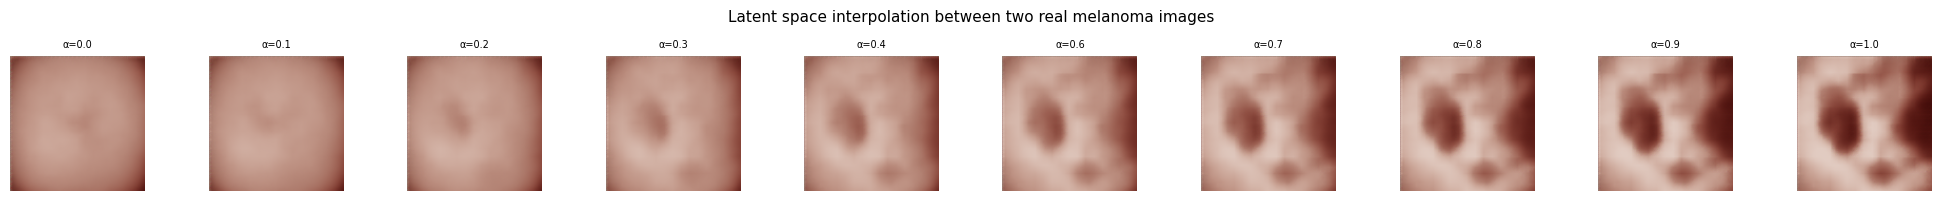

In [17]:
# Interpolation showcase: visualise a smooth walk between two real images
z_a = z_means[0:1]   # First real melanoma image in latent space
z_b = z_means[1:2]   # Second real melanoma image

steps   = 10
alphas  = np.linspace(0, 1, steps).astype(np.float32)
z_walk  = np.array([(1 - a) * z_a + a * z_b for a in alphas]).squeeze(1)
walk_imgs = decoder.predict(z_walk, verbose=0)

fig, axes = plt.subplots(1, steps, figsize=(2 * steps, 2))
for i in range(steps):
    axes[i].imshow(np.clip(walk_imgs[i], 0, 1))
    axes[i].axis("off")
    axes[i].set_title(f"α={alphas[i]:.1f}", fontsize=7)

fig.suptitle("Latent space interpolation between two real melanoma images", fontsize=11)
plt.tight_layout()
plt.show()

In [18]:
# Class balance summary after augmentation
n_real_melanoma = len(melanoma_files)
n_synthetic     = len(synthetic_paths)

# Count actual benign images from training split
all_train_files = [f for f in os.listdir(TRAIN_DIR) if f.endswith(".jpg")]
n_benign = sum(
    1 for f in all_train_files
    if label_dict.get(f.replace(".jpg", "")) == 0
)

new_total_melanoma = n_real_melanoma + n_synthetic
new_ratio = n_benign / new_total_melanoma

print("Class balance summary")
print("-" * 45)
print(f"Benign (real)          : {n_benign:>7,}")
print(f"Melanoma (real)        : {n_real_melanoma:>7,}")
print(f"Melanoma (synthetic)   : {n_synthetic:>7,}")
print(f"Melanoma (total)       : {new_total_melanoma:>7,}")
print(f"New imbalance ratio    : {new_ratio:.1f}:1  (was {n_benign/n_real_melanoma:.1f}:1)")

Class balance summary
---------------------------------------------
Benign (real)          :   2,129
Melanoma (real)        :      31
Melanoma (synthetic)   :   2,000
Melanoma (total)       :   2,031
New imbalance ratio    : 1.0:1  (was 68.7:1)


## 9. Save Models

In [19]:
encoder.save(f"{MODEL_SAVE_DIR}/vae_encoder.keras")
decoder.save(f"{MODEL_SAVE_DIR}/vae_decoder.keras")
print("Encoder and decoder saved.")

Encoder and decoder saved.
